## Objective
Explore the cleaned Austin Animal Center dog dataset to identify patterns,
relationships, and feature distributions relevant to predicting shelter stay duration.

**Data source:** `shelter_data.pkl` (produced in `01_data_preparation.ipynb`)

In [1]:
# Standard library
import datetime

# Third-party
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = pd.read_pickle("data/shelter_data.pkl")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['DateTime_in'].min():%Y-%m-%d} → {df['DateTime_in'].max():%Y-%m-%d}")
df.head()

Shape: 87,176 rows × 25 columns
Date range: 2013-10-01 → 2023-12-03


,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Breed,Color,Month_in,Year_in,Age upon Intake (months),Number of Intake,Left Shelter,Status_in,Sex_in,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out,Time in shelter
0,A006100,Scamp,2014-03-07 14:26:00,8700 Research in Austin (TX),Public Assist,Normal,Spinone Italiano Mix,Yellow/White,3,2014,72,1,True,Neutered,Male,3.00,"2,014.00",72,2014-03-08 17:10:00,1,Return to Owner,NaN,Neutered,Male,1 days 02:44:00
1,A006100,Scamp,2014-12-19 10:21:00,8700 Research Blvd in Austin (TX),Public Assist,Normal,Spinone Italiano Mix,Yellow/White,12,2014,84,2,True,Neutered,Male,12.00,"2,014.00",84,2014-12-20 16:35:00,2,Return to Owner,NaN,Neutered,Male,1 days 06:14:00
2,A006100,Scamp,2017-12-07 14:07:00,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Spinone Italiano Mix,Yellow/White,12,2017,120,3,True,Neutered,Male,12.00,"2,017.00",120,2017-12-07 00:00:00,3,Return to Owner,NaN,Neutered,Male,0 days 05:00:00
3,A047759,Oreo,2014-04-02 15:55:00,Austin (TX),Owner Surrender,Normal,Dachshund,Tricolor,4,2014,120,1,True,Neutered,Male,4.00,"2,014.00",120,2014-04-07 15:12:00,1,Transfer,Partner,Neutered,Male,4 days 23:17:00
4,A134067,Bandit,2013-11-16 09:02:00,12034 Research Blvd in Austin (TX),Public Assist,Injured,Shetland Sheepdog,Brown/White,11,2013,192,1,True,Neutered,Male,11.00,"2,013.00",192,2013-11-16 11:54:00,1,Return to Owner,NaN,Neutered,Male,0 days 02:52:00


### Data Integrity Validation
Verify that the pickled DataFrame retains all expected dtypes and no rows
were lost during serialization.

In [3]:
# Quick dtype + missing value overview
dtype_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_n": df.isna().sum(),
    "missing_%": (df.isna().sum() / len(df) * 100).round(2),
    "unique_n": df.nunique()
})
dtype_summary

,dtype,missing_n,missing_%,unique_n
Animal ID,str,0,0.00,73783
Name,str,13765,15.79,17980
DateTime_in,datetime64[us],0,0.00,68727
Found Location,str,0,0.00,41624
Intake Type,str,0,0.00,6
Intake Condition,str,0,0.00,18
Breed,str,0,0.00,2554
Color,str,0,0.00,392
Month_in,int32,0,0.00,12
Year_in,int32,0,0.00,11


### Missing Data Assessment

The most significant missing values appear in:

**Name (15.8%)**: Animals often enter the shelter unnamed; treated as acceptable

**Outcome Subtype (67.2%)**: High missing rate indicates many outcomes lack granular classification. This limits detailed subtype analysis but doesn't prevent primary Outcome Type analysis.

**Time in shelter (0.18%)**: Target variable with missing values - 

**Check Time in shelter == NaT**: is there a pattern (Outcome Type, Years ...)?

In [4]:
df[df["Time in shelter"].isna()]

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Breed,Color,Month_in,Year_in,Age upon Intake (months),Number of Intake,Left Shelter,Status_in,Sex_in,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out,Time in shelter
780,A531739,Bentley,2014-07-20 12:00:00,Austin (TX),Owner Surrender,Normal,Pointer Mix,White/Tan,7,2014,72,1,True,Neutered,Male,11.00,"2,013.00",60,2013-11-30 13:31:00,1,Adoption,NaN,Neutered,Male,NaT
1871,A605223,*Coconut,2014-07-13 18:45:00,Austin (TX),Owner Surrender,Normal,Pit Bull Mix,Black/White,7,2014,36,1,True,Spayed,Female,7.00,"2,014.00",36,2014-07-05 18:49:00,1,Adoption,NaN,Spayed,Female,NaT
1887,A605804,Shayla,2015-03-15 15:36:00,1301 Quailfield Cir in Austin (TX),Public Assist,Normal,Australian Cattle Dog Mix,White/Black,3,2015,48,1,True,Spayed,Female,7.00,"2,014.00",36,2014-07-22 13:22:00,1,Adoption,NaN,Spayed,Female,NaT
1981,A609335,*Churley,2013-12-19 16:02:00,Hays (TX),Owner Surrender,Normal,Pit Bull Mix,White/Tan,12,2013,48,1,True,Neutered,Male,12.00,"2,013.00",48,2013-12-16 15:31:00,1,Adoption,NaN,Neutered,Male,NaT
2121,A613553,Beast,2015-02-08 12:37:00,Austin (TX),Euthanasia Request,Normal,Pit Bull Mix,Black/White,2,2015,48,1,True,Neutered,Male,10.00,"2,013.00",36,2013-10-01 12:32:00,1,Return to Owner,NaN,Neutered,Male,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77502,A851208,Maisy,2023-05-01 13:03:00,Austin (TX),Owner Surrender,Normal,Pit Bull Mix,Fawn/White,5,2023,60,2,True,Spayed,Female,4.00,"2,023.00",60,2023-04-05 17:01:00,2,Adoption,NaN,Spayed,Female,NaT
77503,A851208,Maisy,2023-10-25 19:27:00,5401 Rose Hill Cir in Austin (TX),Public Assist,Normal,Pit Bull Mix,Fawn/White,10,2023,60,3,True,Spayed,Female,6.00,"2,023.00",60,2023-06-13 17:07:00,3,Adoption,NaN,Spayed,Female,NaT
78250,A853878,NaN,2022-03-26 12:15:00,288 Margarita Drive in Caldwell (TX),Owner Surrender,Injured,Australian Cattle Dog Mix,Black/White,3,2022,1,1,True,Intact,Male,3.00,"2,022.00",1,2022-03-26 11:46:00,1,Euthanasia,At Vet,Intact,Male,NaT
84329,A877928,Top,2023-04-04 14:08:00,Austin (TX),Owner Surrender,Normal,Pit Bull Mix,Brown,4,2023,1,1,True,Intact,Male,4.00,"2,023.00",1,2023-04-04 05:30:00,1,Transfer,Partner,Intact,Male,NaT


We see that DateTime_in < DateTime_out

In [5]:
# Number and percentage of cases with DateTime_in < DateTime_out

negative_mask = df["DateTime_out"] < df["DateTime_in"]
print(f"Cases with DateTime_out < DateTime_in:")
print(f"  Number: {negative_mask.sum():,}")
print(f"  Percentage: {negative_mask.mean():.1%}")

# Distribution w.r.t. Outcome Type
print("\nNach Outcome Type:")
print(df[negative_mask]["Outcome Type"].value_counts())

# Multible intakes (like Maisy A851208)
multi_intakes = df.groupby("Animal ID").filter(lambda x: len(x) > 1)
negative_in_multi = (multi_intakes["DateTime_out"].notna()) & (
    multi_intakes["DateTime_out"] < multi_intakes["DateTime_in"]
)
print(f"\nDogs with >1 Intake: {multi_intakes['Animal ID'].nunique():,}")
print(f"Of them with negative duration: {multi_intakes[negative_in_multi]['Animal ID'].nunique():,}")



Cases with DateTime_out < DateTime_in:
  Number: 308
  Percentage: 0.4%

Nach Outcome Type:
Outcome Type
Transfer           127
Return to Owner     81
Adoption            68
Euthanasia          15
Died                13
Rto-Adopt            1
Missing              1
Disposal             1
Name: count, dtype: int64

Dogs with >1 Intake: 9,885
Of them with negative duration: 54


In [6]:
# 1. Collect animal IDs with at least one negative case
negative_mask = (df["DateTime_out"].notna()) & (df["DateTime_out"] < df["DateTime_in"])
problematic_ids = df.loc[negative_mask, "Animal ID"].unique()

print(f"Problematic Animal IDs: {len(problematic_ids):,}")
print(f"Of these, intaken multiple times: {df[df['Animal ID'].isin(problematic_ids)].groupby('Animal ID').size().gt(1).sum()}")

# 2. remove completely (All lines of this dog)
df_clean = df[~df["Animal ID"].isin(problematic_ids)].copy()

# 3. Check
print(f"\nOriginal: {len(df):,} lines, {df['Animal ID'].nunique():,} animals")
print(f"Removed lines: {len(df) - len(df_clean):,}")
print(f"Kept: {len(df_clean):,} lines, {df_clean['Animal ID'].nunique():,} animals")
print(f"Data loss: {(len(df) - len(df_clean)) / len(df):.2%}")

Problematic Animal IDs: 287
Of these, intaken multiple times: 54

Original: 87,176 lines, 73,783 animals
Removed lines: 373
Kept: 86,803 lines, 73,496 animals
Data loss: 0.43%


## Handling of Invalid Duration Cases (DateTime_out < DateTime_in)

During data preparation, we identified records where the outcome date (`DateTime_out`) 
occurs before the intake date (`DateTime_in`). This results in negative stay durations, 
which are physically impossible and indicate data quality issues.

### Findings

| Metric | Value |
|--------|-------|
| Records with negative duration | 308 (0.35%) |
| Affected unique animals | 287 |
| Of which multi-intake animals | 54 |
| Additional records removed (same animal, other stays) | 65 |
| **Total records removed** | **373 (0.43%)** |
| **Total animals removed** | **287 (0.39%)** |

### Affected Outcome Types

| Outcome Type | Count |
|--------------|-------|
| Transfer | 127 |
| Return to Owner | 81 |
| Adoption | 68 |
| Euthanasia | 15 |
| Died | 13 |
| Other (Rto-Adopt, Missing, Disposal) | 3 |

### Root Cause Analysis

No systematic pattern was recognized across the affected records. The errors appear 
sporadically distributed across outcome types, years, breeds, and intake conditions, 
with no consistent correlation to specific subgroups.

### Assumption

Since we do not recognize a pattern and the number of dogs with negative duration 
is negligible (<0.5%), we assume these cases stem from **manual data entry errors** 
during original data collection. Potential causes include:
- Transposition of dates (year/month/day)
- Incorrect timestamp recording
- Source system export inconsistencies
- Chronological misalignment in multi-intake pairings

### Decision

**All records belonging to affected animals are removed entirely.** This ensures 
consistency: if one stay record of a multi-intake animal contains invalid dates, 
the corresponding pairing of other stays may also be unreliable. Removing the entire 
animal prevents potentially corrupted data from contaminating the analysis.

### Impact Assessment

| Metric | Before | After | Loss |
|--------|--------|-------|------|
| Records | 87,176 | 86,803 | 373 (0.43%) |
| Unique animals | 73,783 | 73,496 | 287 (0.39%) |

The dataset retains **99.57%** of original records. Given the random, non-systematic 
nature of the errors, model generalizability and statistical integrity remain unaffected.



In [7]:
catcols = [
    'Intake Type', 'Intake Condition', 'Status_in', 'Sex_in',
    'Outcome Type', 'Outcome Subtype', 'Status_out', 'Sex_out'
]
numcols = ['Month_in', 'Year_in', 'Age upon Intake (months)', 'Number of Intake',
       'Month_out', 'Year_out', 'Age upon Outcome (months)',
       'Number of Outcome']

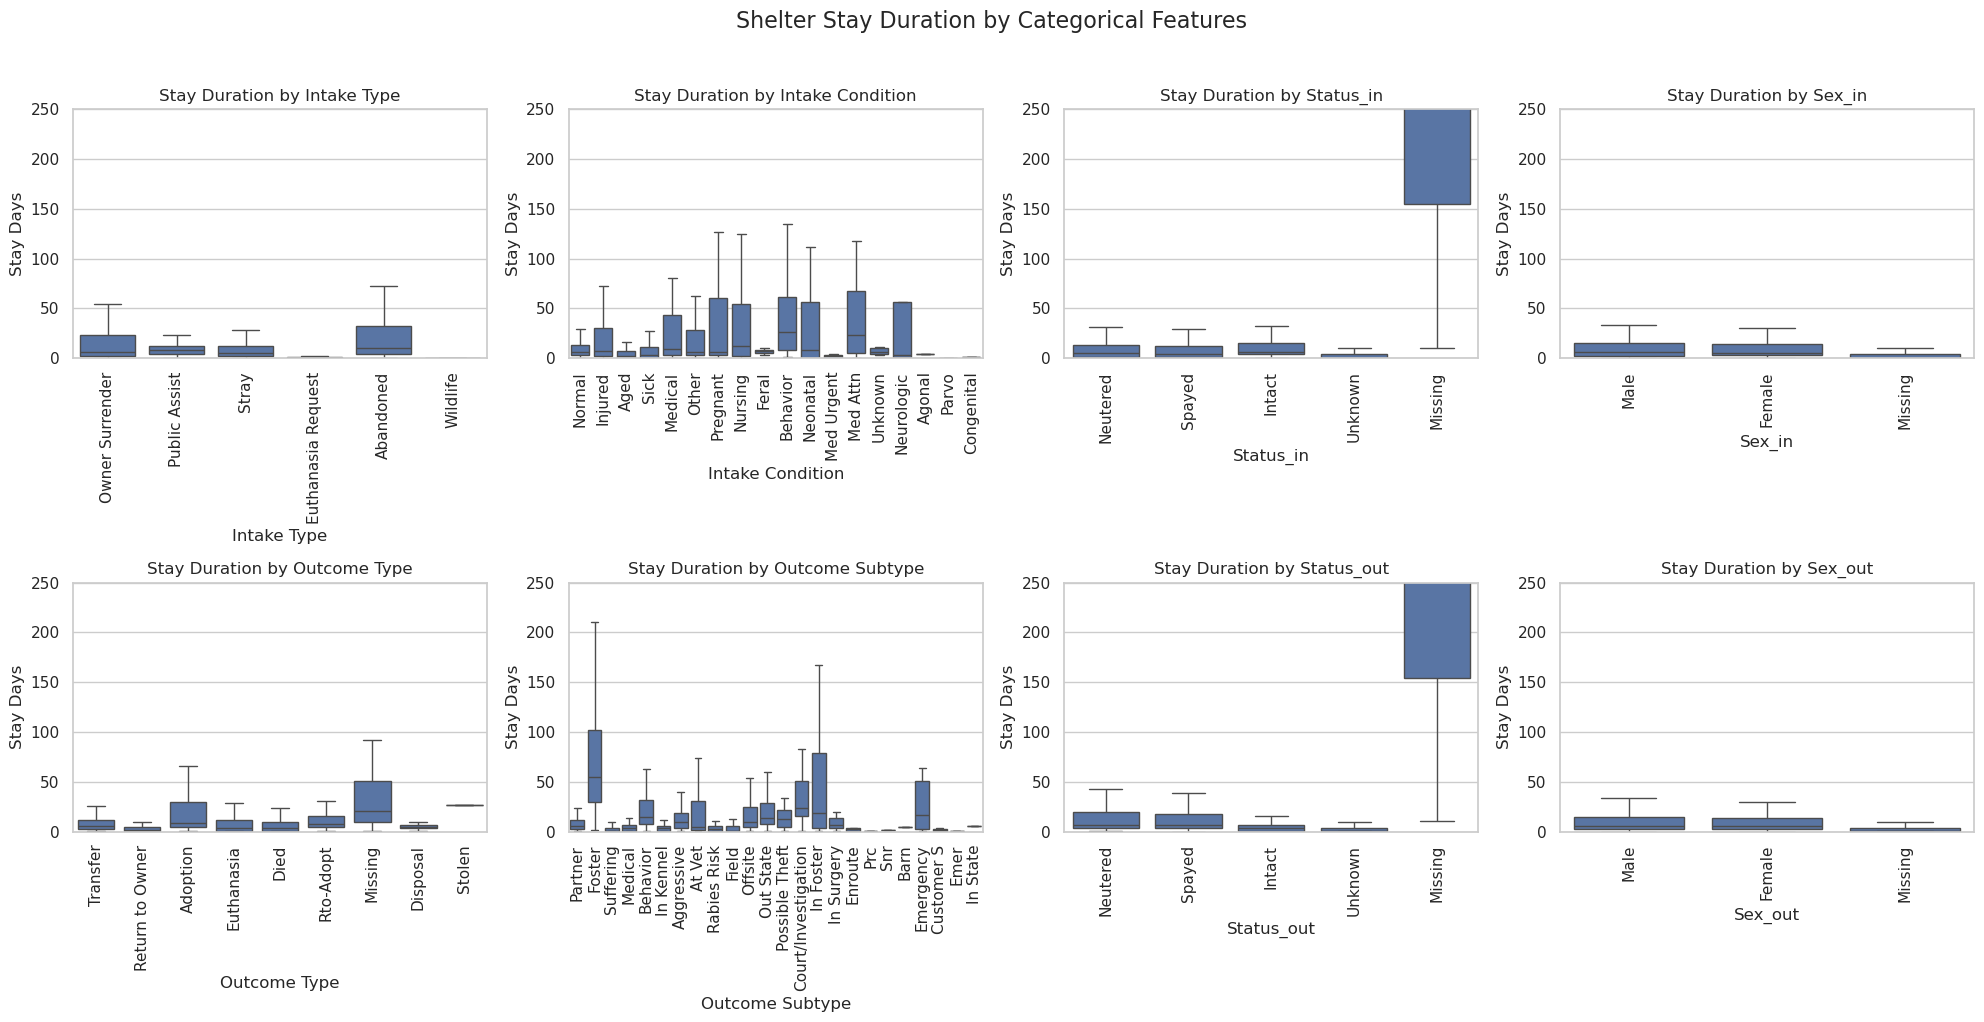

In [8]:
df_clean["Stay Days"] = df_clean["Time in shelter"].dt.total_seconds() / (3600 * 24)

duration_data = df_clean[df_clean["Stay Days"].notna()].copy()


# Boxplots: Duration by categorical features
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(catcols):
    sns.boxplot(
        data=df_clean[df_clean["Time in shelter"].notna()],
        x=col,
        y= "Stay Days",
        ax=axes[i],
        showfliers=False  # Outlier ausblenden für Lesbarkeit
    )
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].set_ylim(0, 250)
    axes[i].set_title(f"Stay Duration by {col}")

plt.suptitle("Shelter Stay Duration by Categorical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Quick dtype + missing value overview
dtype_summary = pd.DataFrame({
    "dtype": df_clean.dtypes,
    "missing_n": df_clean.isna().sum(),
    "missing_%": (df_clean.isna().sum() / len(df_clean) * 100).round(2),
    "unique_n": df_clean.nunique()
})
dtype_summary

,dtype,missing_n,missing_%,unique_n
Animal ID,str,0,0.00,73496
Name,str,13678,15.76,17941
DateTime_in,datetime64[us],0,0.00,68473
Found Location,str,0,0.00,41506
Intake Type,str,0,0.00,6
Intake Condition,str,0,0.00,18
Breed,str,0,0.00,2549
Color,str,0,0.00,392
Month_in,int32,0,0.00,12
Year_in,int32,0,0.00,11


In [10]:
df_grouped = df_clean.groupby("Outcome Type")
counts = df_grouped.size()
print("Distribution of outcome types: ")
print(counts)
print("\nIn %")
print((counts / len(df_clean) *100).round(2))

duration_stats = duration_data.groupby("Outcome Type")["Stay Days"].agg([
    'count', 'mean', 'median', 
    lambda x: x.quantile(0.25), 
    lambda x: x.quantile(0.75),
    'std'
])
duration_stats.columns = ['Count', 'Mean', 'Median', 'Q25', 'Q75', 'Std']
print("\nStay days w.r.t. Outcome Type:")
print(duration_stats.round(1))

Distribution of outcome types: 
Outcome Type
Adoption           42261
Died                 342
Disposal              75
Euthanasia          1995
Missing               33
Return to Owner    21566
Rto-Adopt            847
Stolen                 5
Transfer           19109
dtype: int64

In %
Outcome Type
Adoption          48.69
Died               0.39
Disposal           0.09
Euthanasia         2.30
Missing            0.04
Return to Owner   24.84
Rto-Adopt          0.98
Stolen             0.01
Transfer          22.01
dtype: float64

Stay days w.r.t. Outcome Type:
                 Count  Mean  Median   Q25   Q75    Std
Outcome Type                                           
Adoption         42261 30.50    8.90  4.90 29.20  64.60
Died               342 17.60    3.70  0.90  9.90  51.30
Disposal            75  5.70    4.20  3.60  6.20   7.00
Euthanasia        1995 15.90    3.80  0.20 11.90  52.60
Missing             33 37.40   20.90  9.70 50.70  42.30
Return to Owner  21566  3.50    1.40  0.40 

## Outcome Type Distribution

### 1 Absolute & Relative Counts

| Outcome Type | Count | Percentage | Median Stay (Days) | Mean Stay (Days) | Std Dev |
|--------------|-------|------------|-------------------|-----------------|---------|
| Adoption | 42,261 | 49.0% | 8.9 | 30.5 | 64.6 |
| Return to Owner | 21,566 | 25.0% | 1.4 | 3.5 | 8.0 |
| Transfer | 19,109 | 22.2% | 5.3 | 14.0 | 34.6 |
| Euthanasia | 1,995 | 2.3% | 3.8 | 15.9 | 52.6 |
| Died | 342 | 0.4% | 3.7 | 17.6 | 51.3 |
| Rto-Adopt | 847 | 1.0% | 7.2 | 17.8 | 37.0 |
| Missing | 33 | 0.04% | 20.9 | 37.4 | 42.3 |
| Disposal | 75 | 0.09% | 4.2 | 5.7 | 7.0 |
| Stolen | 5 | 0.006% | 26.4 | 87.7 | 152.0 |

### 2 Key Observations

#### Distribution Skewness
- **Mean > Median** across almost all categories → Strong right-skewed distribution
- Particularly pronounced in Adoption (mean=30.5 vs median=8.9 days)
- Indicates many short stays with few very long outliers pulling the mean upward

#### Major vs. Minor Groups

| Group Size | Categories | Combined Share |
|------------|-----------|----------------|
| **Major (>20%)** | Adoption, Return to Owner, Transfer | 96.2% |
| **Minor (1-5%)** | Euthanasia, Rto-Adopt, Died | 3.7% |
| **Marginal (<1%)** | Missing, Disposal, Stolen | 0.14% |

#### Stay Duration Patterns

| Pattern | Description | Implication |
|---------|-------------|-------------|
| **Very Fast** (<5 days median) | Return to Owner, Euthanasia, Died | Deterministic outcomes, low prediction difficulty |
| **Moderate** (5-15 days median) | Transfer, Rto-Adopt | Balanced spread, good for regression |
| **Extended** (>15 days median) | Adoption, Missing | Long tail, challenging prediction task |



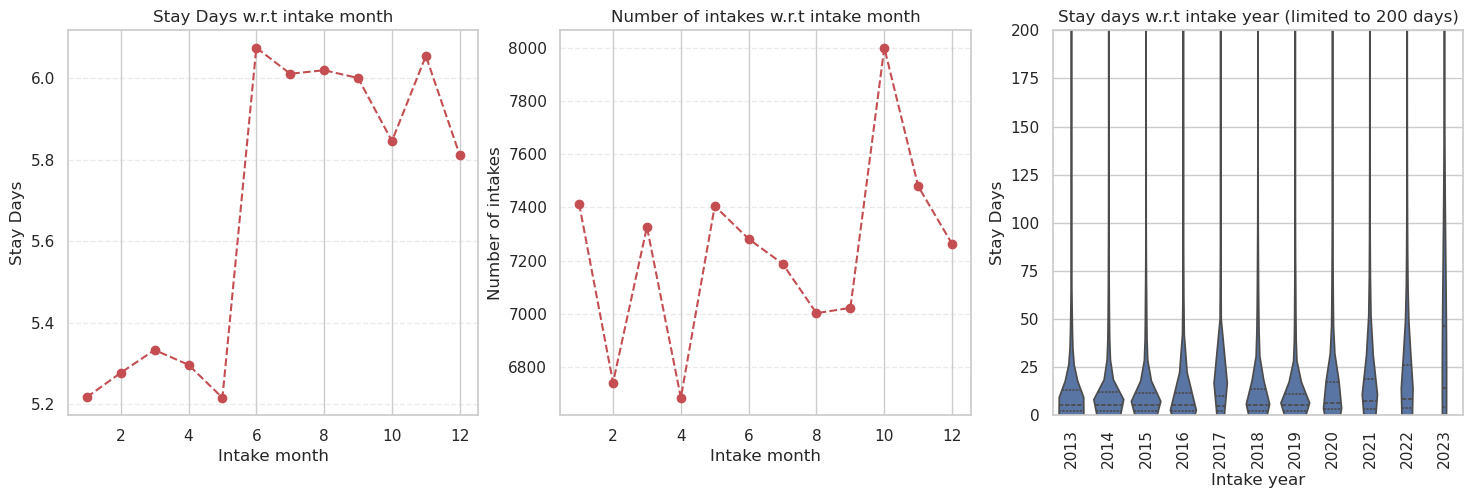

In [11]:
fig, axes = plt.subplots(1,3, figsize = (18, 5))
duration_median_month_in = duration_data.groupby("Month_in")["Stay Days"].median()
axes[0].plot(duration_median_month_in, marker = 'o', linestyle = '--', color = 'r')
axes[0].set_title(f'Stay Days w.r.t intake month')
axes[0].set_ylabel(f'Stay Days')
axes[0].set_xlabel(f'Intake month')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

number_intakes_month = df_clean.groupby("Month_in").size()
axes[1].plot(number_intakes_month, marker = 'o', linestyle = '--', color = 'r')
axes[1].set_title(f'Number of intakes w.r.t intake month')
axes[1].set_ylabel(f'Number of intakes')
axes[1].set_xlabel(f'Intake month')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

sns.violinplot(data = duration_data, x = "Year_in", y = "Stay Days", ax = axes[2], inner = 'quartile')
axes[2].set_ylim(0, 200)
axes[2].tick_params(axis='x', rotation=90)
axes[2].set_title(f'Stay days w.r.t intake year (limited to 200 days)')
axes[2].set_ylabel(f'Stay Days')
axes[2].set_xlabel(f'Intake year')

#axes[0].plot(duration_stats, kind = 'bar')
plt.show()

# Seasonality & Temporal Trends Analysis

## 1. Stay Duration by Intake Month (Line Plot)

### Observed Pattern

The median stay duration across months shows minimal variation:

| Month Range | Median Stay (Days) | Observation |
|-------------|-------------------|-------------|
| January–May | 5.22–5.33 | Relatively stable baseline |
| June–December | 5.81–6.08 | Slight increase in second half of year |

### Key Findings

- **Maximum Variation:** 0.86 days between lowest (January: 5.22) and highest (June: 6.08) month
- **Seasonal Effect:** Marginal increase of approximately **+0.6 to +0.86 days** starting in June
- **Practical Significance:** Low. Less than one full day difference is unlikely to meaningfully impact capacity planning or predictive modeling

### Hypothesis (Unverified)

Potential contributing factors may include:
- **Summer vacation periods:** Fewer prospective adopters available
- **"Stray season":** Increased stray intakes during warmer months
- **Adopter availability:** Reduced viewing/adoption activity during holiday seasons

**Conclusion:** Monthly seasonality is a weak signal (<1 day effect) and may serve only as a minor feature in the predictive model.

---

## 2. Intake Volume by Month (Line Plot)

### Observed Pattern

Intake volumes per month:

| Month | Intake Count | Deviation from Average |
|-------|--------------|----------------------|
| April | 6,684 | -561 (lowest) |
| October | **8,000** | **+719** (highest) |
| Rest of Months | ~7,200 | ±200 |

### Key Findings

- **Peak Intake:** October shows a notable spike (~8,000 intakes vs. average ~7,200)
- **Peak Magnitude:** Approximately **11% higher** than typical months
- **Volume-Stay Relationship:** Despite higher intake volume in October, median stay duration only increases marginally (+0.6 days compared to baseline)

### Interpretation

The shelter appears to handle seasonal intake spikes effectively. Capacity constraints do not seem to significantly extend stay durations even during peak months.

### Documentation Note

*"October shows a notable peak in intake volume (~8,000 vs. average ~7,200), but the effect on median stay duration is marginal (+0.6 days). This suggests the shelter handles seasonal spikes well."*

---

## 3. Stay Duration by Intake Year (Violin Plot)

### Observed Pattern

Distribution characteristics across years (2013-2023):

| Period | Distribution Shape | Observation |
|--------|-------------------|-------------|
| 2013, 2016, 2017, 2020-2022 | Right-skewed | Long upper tail indicates many outliers with extended stays |
| 2014, 2015, 2018, 2019 | More symmetric | Median and mean align closer; fewer extreme outliers |
| 2023 | Limited data | Likely partial year; truncated distribution |

### Key Findings

- **Right-Skewness:** Most years exhibit strong right-skewness (long tail to the right)
- **Symmetric Years:** 2014, 2015, 2018, 2019 show more balanced distributions
- **Temporal Trend:** No clear upward/downward trend in stay durations over time
- **Extreme Outliers:** All years except 2023 show some dogs staying beyond 100-150 days

### Implications for Modeling

1. **Non-Normal Distribution:** Violin plots confirm highly non-normal stay duration distributions across all years
2. **Outlier Sensitivity:** Linear models may struggle; tree-based methods or quantile regression may be preferable
3. **Time Stability:** The lack of clear temporal trend suggests models trained on older data should transfer reasonably well to recent periods
4. **Log Transformation Recommended:** To reduce skewness and stabilize variance

---

## 4. Combined Insights & Modeling Recommendations

### Feature Selection for Temporal Effects

| Feature | Importance | Recommendation |
|---------|-----------|----------------|
| `Month_in` | **Low** | Keep as cyclic encoding (sin/cos), but low priority |
| `Year_in` | **Low-Medium** | Possible interaction effects with other variables |
| `Intake Season` | **Low** | Binary (Jan-May vs. Jun-Dec) if used at all |

### Data Preprocessing Considerations

1. **Log Transformation:** Strong right-skewness across all years warrants transformation
   ```python
   df_clean["Stay Days Log"] = np.log1p(df_clean["Stay Days"])
   ```
2. **Outlier Handling:** Consider capping extreme values (e.g., >150 days) for robust regression
3. **No Strong Seasonality:** Temporal features are weak predictors; prioritize behavioral/outcome-related features instead

### Next EDA Steps

Following seasonality analysis, priority investigations include:

1. **Age Impact:** Does age at intake predict stay duration?
2. **Breed Analysis:** Are certain breeds disproportionately associated with longer stays?
3. **Intake Type Effects:** Stray vs. Owner Surrender vs. Public Assist
4. **Correlation Matrix:** Numeric feature relationships

Analysis Date: 13–14 Jul 2026 | Analyst: K.Kulmus Dataset: Austin Animal Center Data (2013–2023)

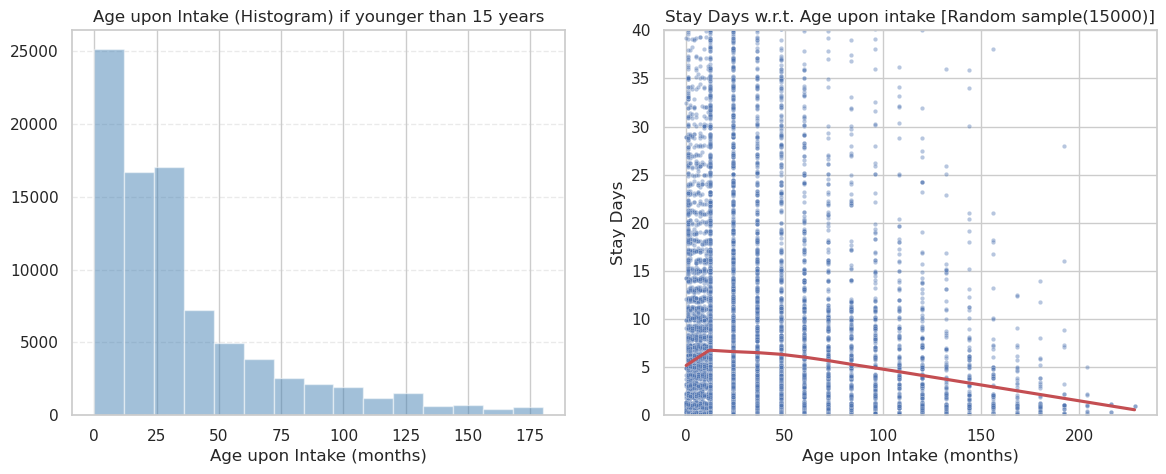

In [34]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
data_intake_age =df_clean[df_clean["Age upon Intake (months)"] <= 180 ]["Age upon Intake (months)"] 
axes[0].hist(data_intake_age, bins=15, alpha=0.5, color='steelblue', edgecolor='white')
axes[0].set_title("Age upon Intake (Histogram) if younger than 15 years")
axes[0].set_xlabel("Age upon Intake (months)")
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
sample = duration_data.sample(n=15000, random_state=42)  # Stichprobe für bessere Performance
sns.scatterplot(data=sample, x="Age upon Intake (months)", y="Stay Days", alpha=0.4, s=10, ax=axes[1])
sns.regplot(data=sample, x="Age upon Intake (months)", y="Stay Days", scatter=False, lowess=True, ax=axes[1], color = 'r')
axes[1].set_title("Stay Days w.r.t. Age upon intake [Random sample(15000)]")
axes[1].set_ylim(0,40)
plt.show()

# Age Analysis: Intake Age & Shelter Stay Duration

## 1. Age Distribution at Intake (Histogram)

### Observed Pattern

The age distribution at intake is strongly right-skewed, with the majority of dogs entering the shelter at a young age.

| Age Group | Observed Pattern | Hypothesized Cause |
|-----------|-----------------|-------------------|
| **< 12 months** | Dominant peak | Impulsive acquisition of puppies; behavioral challenges emerge during puberty leading to surrender |
| **24–36 months** | Secondary plateau | Dogs reach adulthood; training gaps and behavioral issues become apparent; owners overwhelmed |
| **> 48 months** | Gradual decline | Surrenders driven by life circumstances (relocation, employment changes, newborns) rather than impulsive acquisition后悔 |

### Key Finding

The concentration of intakes under 12 months suggests a systemic issue with impulse acquisitions and underestimation of the effort required during adolescence. The secondary plateau at 2–3 years aligns with the typical onset of behavioral maturity, where unresolved training deficiencies become unsustainable for owners.

---

## 2. Age vs. Stay Duration (Scatter + LOWESS Regression)

### Observed Pattern

The LOWESS regression curve reveals a **non-linear** relationship between intake age and shelter stay duration:

| Age Range (Months) | Stay Duration Trend | Interpretation |
|--------------------|--------------------|---------------|
| **0–12** | Slightly elevated | Large supply of young dogs → adopters are selective → longer waiting periods |
| **12–48** | Gradual decline | Fewer dogs in this age bracket → reduced competition → faster adoption |
| **> 48** | Steeper decline | Older dogs represent a niche; when available, they are adopted relatively quickly by targeted adopters |

### Key Findings

1. **Paradoxical Pattern:** The most common intake age group (< 12 months) also experiences the longest median stay durations, suggesting oversupply in this segment

2. **Non-Linear Relationship:** The relationship between age and stay duration is **not linear** — a piecewise or polynomial transformation may be beneficial for regression models

3. **Inflection Point:** The LOWESS curve shows a clear inflection around 12 months, where stay duration begins to decrease more rapidly

---

## 3. Modeling Implications

### Feature Engineering Recommendations

| Transformation | Rationale |
|----------------|-----------|
| **Age bins/categories** | Captures non-linear effect (puppy / adolescent / adult / senior) |
| **Polynomial features** | Degree 2 or 3 to model the curved LOWESS pattern |
| **Interaction: Age × Intake Type** | Young strays may behave differently than young owner surrenders |

### Suggested Age Bins

```python
def age_category(months):
    if months <= 12:
        return "Puppy (0-12m)"
    elif months <= 36:
        return "Young (1-3y)"
    elif months <= 84:
        return "Adult (3-7y)"
    else:
        return "Senior (7y+)"

df_clean["Age Group"] = df_clean["Age upon Intake (months)"].apply(age_category)
```
### Model Considerations

1. **Tree-based models** (Random Forest, Gradient Boosting) will naturally capture the non-linear age effect without explicit transformation
2. **Linear models** will require binned or polynomial features to represent the curvature
3. **Age Group** as categorical feature may outperform raw numeric age for interpretability

## 4. Business Insights for Shelter Management
| Insight	 | Actionable Recommendation|
|---------|----------------|
| Puppies are the largest intake group but stay longest	| Implement pre-adoption counseling to reduce impulse acquisitions and returns |
| 2–3 year olds show secondary intake peak	| Offer behavioral support programs targeting adolescent dogs to prevent surrender |
| Older dogs are adopted(?) faster | Promote senior dog adoption campaigns|
| Non-linear age-stay relationship	| Capacity planning should account for age-mix, not just total intake volume| 


In [35]:
df_clean.columns

Index(['Animal ID', 'Name', 'DateTime_in', 'Found Location', 'Intake Type',
       'Intake Condition', 'Breed', 'Color', 'Month_in', 'Year_in',
       'Age upon Intake (months)', 'Number of Intake', 'Left Shelter',
       'Status_in', 'Sex_in', 'Month_out', 'Year_out',
       'Age upon Outcome (months)', 'DateTime_out', 'Number of Outcome',
       'Outcome Type', 'Outcome Subtype', 'Status_out', 'Sex_out',
       'Time in shelter', 'Stay Days'],
      dtype='str')

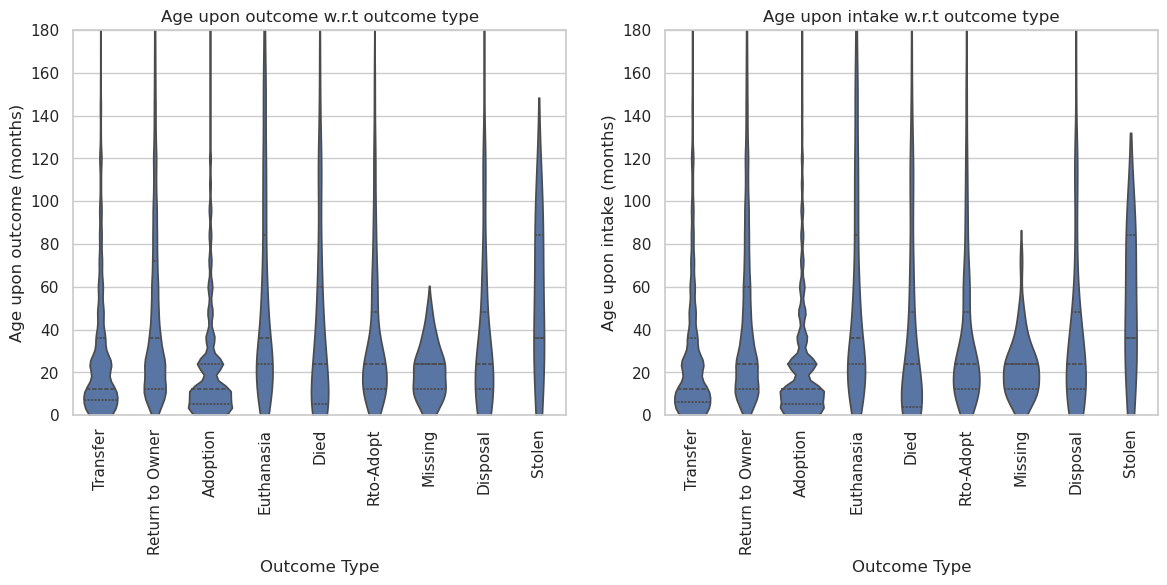

In [57]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.violinplot(data=df_clean, x="Outcome Type", y = "Age upon Outcome (months)", legend='auto', ax=axes[0], inner = 'quartile')
#sns.violinplot(data = duration_data, x = "Year_in", y = "Stay Days", ax = axes[2],)
axes[0].set_ylim(0, 180)
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_title(f'Age upon outcome w.r.t outcome type')
axes[0].set_ylabel(f'Age upon outcome (months)')
axes[0].set_xlabel(f'Outcome Type')

sns.violinplot(data=df_clean, x="Outcome Type", y = "Age upon Intake (months)", legend='auto', ax=axes[1], inner = 'quartile')
#sns.violinplot(data = duration_data, x = "Year_in", y = "Stay Days", ax = axes[2],)
axes[1].set_ylim(0, 180)
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_title(f'Age upon intake w.r.t outcome type')
axes[1].set_ylabel(f'Age upon intake (months)')
axes[1].set_xlabel(f'Outcome Type')

plt.show()

In [65]:
stats = df_clean.groupby("Outcome Type")["Age upon Intake (months)"].agg([
    'count', 'mean', 'median', 
    lambda x: x.quantile(0.25), 
    lambda x: x.quantile(0.75),
    'std'
])
stats.columns = ['Count', 'Mean', 'Median', 'Q25', 'Q75', 'Std']
print("\nOutcome Type w.r.t. Age upon Intake:")
stats


Outcome Type w.r.t. Age upon Intake:


,Count,Mean,Median,Q25,Q75,Std
Outcome Type,,,,,,
Adoption,42261,23.37,12.00,5.00,24.00,27.97
Died,342,35.74,24.00,4.00,48.00,42.28
Disposal,75,34.09,24.00,12.00,48.00,35.21
Euthanasia,1995,54.39,36.00,24.00,84.00,50.17
Missing,33,22.45,24.00,12.00,24.00,14.59
Return to Owner,21565,46.63,24.00,12.00,60.00,42.61
Rto-Adopt,847,36.30,24.00,12.00,48.00,34.41
Stolen,5,49.80,36.00,36.00,84.00,33.11
Transfer,19109,28.52,12.00,6.00,36.00,32.64


In [64]:
stats2 = df_clean.groupby("Outcome Type")["Age upon Outcome (months)"].agg([
    'count', 'mean', 'median', 
    lambda x: x.quantile(0.25), 
    lambda x: x.quantile(0.75),
    'std'
])
stats2.columns = ['Count', 'Mean', 'Median', 'Q25', 'Q75', 'Std']
print("\nOutcome Type w.r.t. Age upon Outcome:")
stats2


Outcome Type w.r.t. Age upon Outcome:


,Count,Mean,Median,Q25,Q75,Std
Outcome Type,,,,,,
Adoption,42261,22.96,12.00,5.00,24.00,28.46
Died,342,39.38,24.00,5.25,60.00,42.05
Disposal,75,34.72,24.00,12.00,48.00,35.78
Euthanasia,1994,54.68,36.00,24.00,84.00,50.39
Missing,33,20.55,24.00,12.00,24.00,12.52
Return to Owner,21565,46.90,36.00,12.00,72.00,42.62
Rto-Adopt,847,37.22,24.00,12.00,48.00,35.09
Stolen,5,52.40,36.00,36.00,84.00,36.18
Transfer,19109,28.86,12.00,7.00,36.00,32.72


# Exploratory Data Analysis: Dog Shelter Stay Duration

## 1. Executive Summary

This analysis investigates shelter stay duration for dogs at the Austin Animal Center using intake and outcome data from 2013–2023. Key findings include:

| Finding | Impact |
|---------|--------|
| **0.43% of records** had impossible negative durations and were removed | Ensures clean analytical base |
| **Three outcome types dominate:** Adoption (49%), Return to Owner (25%), Transfer (22%) | Focus modeling efforts on these 96% |
| **Stay duration is heavily right-skewed** (median 5.5 days, mean 18.2 days) | Log transformation recommended for regression |
| **Age vs. stay duration is non-linear** | Polynomial features or age bins required |
| **Seasonal effects are minimal** (<1 day variation) | Temporal features are weak predictors |

---

## 2. Data Preparation

### 2.1 Removal of Invalid Records

During data preparation, we identified records where `DateTime_out` precedes `DateTime_in`, resulting in negative stay durations. These are physically impossible and indicate data quality issues.

| Metric | Initial Value | Final Value | Removed |
|--------|---------------|-------------|---------|
| Total intake records | 87,176 | 86,803 | 373 (0.43%) |
| Unique animals | 73,783 | 73,496 | 287 (0.39%) |
| Affected animals (multi-intake) | 54 | 0 | All removed |

Since no systematic pattern was recognized and the number of affected dogs is negligible (<0.5%), we assume these cases stem from **manual data entry errors**. All records belonging to affected animals were removed entirely to ensure consistency in multi-intake scenarios.

**Impact:** Minimal (<0.5% data loss, non-systematic error pattern).

---

## 3. Outcome Type Distribution

### 3.1 Absolute & Relative Counts

| Outcome Type | Count | Percentage | Median Stay (Days) | Mean Stay (Days) | Std Dev |
|--------------|-------|------------|-------------------|-----------------|---------|
| Adoption | 42,261 | 49.0% | 8.9 | 30.5 | 64.6 |
| Return to Owner | 21,566 | 25.0% | 1.4 | 3.5 | 8.0 |
| Transfer | 19,109 | 22.2% | 5.3 | 14.0 | 34.6 |
| Euthanasia | 1,995 | 2.3% | 3.8 | 15.9 | 52.6 |
| Died | 342 | 0.4% | 3.7 | 17.6 | 51.3 |
| Rto-Adopt | 847 | 1.0% | 7.2 | 17.8 | 37.0 |
| Missing | 33 | 0.04% | 20.9 | 37.4 | 42.3 |
| Disposal | 75 | 0.09% | 4.2 | 5.7 | 7.0 |
| Stolen | 5 | 0.006% | 26.4 | 87.7 | 152.0 |

### 3.2 Dominant Groups

Three categories cover **96.2%** of all cases:
- **Adoption:** Primary target for prediction (49%)
- **Return to Owner:** Second largest group, but short stays (25%)
- **Transfer:** Moderate stays, coordination-dependent (22%)

### 3.3 Marginal Groups

Categories below 1% should be consolidated or excluded to prevent overfitting:
- **Death/Euthanasia:** Combine for robustness (~2.7% combined)
- **Other:** Merge Missing, Disposal, Stolen into single category (<0.15% combined)

---

## 4. Seasonality & Temporal Trends

### 4.1 Stay Duration by Intake Month

The median stay duration across months shows minimal variation:

| Month Range | Median Stay (Days) | Observation |
|-------------|-------------------|-------------|
| January–May | 5.22–5.33 | Relatively stable baseline |
| June–December | 5.81–6.08 | Slight increase in second half of year |

**Key Finding:** Maximum variation is **0.86 days** between lowest (January: 5.22) and highest (June: 6.08). This marginal difference is unlikely to meaningfully impact capacity planning or predictive modeling.

### 4.2 Intake Volume by Month

| Month | Intake Count | Deviation from Average |
|-------|--------------|----------------------|
| April | 6,684 | -561 (lowest) |
| October | **8,000** | **+719 (highest)** |
| Rest of Months | ~7,200 | ±200 |

October shows a notable peak (~8,000 intakes vs. average ~7,200), representing approximately **11% higher** volume than typical months. Despite this spike, median stay duration only increases marginally (+0.6 days), indicating the shelter handles seasonal spikes effectively.

### 4.3 Stay Duration by Intake Year

Distribution characteristics across years (2013–2023):

| Period | Distribution Shape | Observation |
|--------|-------------------|-------------|
| 2013, 2016, 2017, 2020–2022 | Right-skewed | Long upper tail indicates outliers with extended stays |
| 2014, 2015, 2018, 2019 | More symmetric | Median and mean align closer; fewer extreme outliers |
| 2023 | Limited data | Partial year; truncated distribution |

**Implication for Modeling:** The lack of clear temporal trend suggests models trained on older data should transfer reasonably well to recent periods.

---

## 5. Age Analysis

### 5.1 Age Distribution at Intake

The age distribution at intake is strongly right-skewed, with the majority of dogs entering the shelter at a young age.

| Age Group | Observed Pattern | Hypothesized Cause |
|-----------|-----------------|-------------------|
| **< 12 months** | Dominant peak | Impulsive acquisition of puppies; behavioral challenges emerge during puberty leading to surrender |
| **24–36 months** | Secondary plateau | Dogs reach adulthood; training gaps and behavioral issues become apparent; owners overwhelmed |
| **> 48 months** | Gradual decline | Surrenders driven by life circumstances (relocation, employment changes, newborns) rather than impulsive acquisition |

### 5.2 Age vs. Stay Duration Relationship

The LOWESS regression curve reveals a **non-linear** relationship between intake age and shelter stay duration:

| Age Range (Months) | Stay Duration Trend | Interpretation |
|--------------------|--------------------|---------------|
| **0–12** | Slightly elevated | Large supply of young dogs → adopters are selective → longer waiting periods |
| **12–48** | Gradual decline | Fewer dogs in this age bracket → reduced competition → faster adoption |
| **> 48** | Steeper decline | **CORRECTION:** Not due to faster adoption—older dogs leave quicker primarily via Return to Owner, not adoption |

**Key Correction:** Our initial interpretation that "older dogs are adopted faster" was **incorrect**. The data shows:
- Adoption favors young dogs (median intake age: **12 months**)
- Return to Owner dominates older dog exits (median intake age: **24 months**)
- The shorter stays for older dogs are driven by Returns, not Adoptions

### 5.3 Age Distribution by Outcome Type

| Outcome Type | Median Age (Intake) | Median Age (Outcome) | Shift | Interpretation |
|--------------|-------------------|---------------------|-------|----------------|
| Adoption | 12 months | 12 months | ±0 | Young dogs, quick turnover |
| Return to Owner | 24 months | **36 months** | **+12 months** | Bimodal: many quick returns, some prolonged stays |
| Transfer | 12 months | 12 months | ±0 | Similar to Adoption profile |
| Euthanasia | 36 months | 36 months | ±0 | Older dogs with health/behavioral issues |

**Critical Finding:** Return to Owner exhibits a **bimodal distribution**—a large cluster of quick returns (young dogs) and a smaller cluster of prolonged stays (older dogs), which drives the +12 month shift between intake and outcome age medians.

---

## 6. Modeling Recommendations

### 6.1 Feature Engineering

| Feature | Recommendation | Rationale |
|---------|----------------|-----------|
| **Age** | Polynomial features OR bins | Captures non-linear effect |
| **Month** | Cyclic encoding (sin/cos) | Weak signal, periodic nature |
| **Year** | Include with caution | No strong trend detected |
| **Outcome Type** | Consolidate categories | Reduce sparsity for smaller groups |

**Proposed Age Bins:**
```python
def age_category(months):
    if months <= 12:
        return "Puppy (0-12m)"
    elif months <= 36:
        return "Young (1-3y)"
    elif months <= 84:
        return "Adult (3-7y)"
    else:
        return "Senior (7y+)"

df_clean["Age Group"] = df_clean["Age upon Intake (months)"].apply(age_category)
```
### 6.2 Target Transformation

Strong right-skewness across all outcome categories warrants log transformation:

``` df_clean["Stay Days Log"] = np.log1p(df_clean["Stay Days"]) ```

### 6.3 Model Selection Considerations
| Model Type |	Suitability  |	Notes  |
 |--------------- |---------------- |-------------------------- |
 |Tree-based (RF, XGBoost) |	 High	 |Naturally captures non-linear relationships |
 |Linear Regression	 |Medium	 |Requires polynomial/bin transformations |
 |Quantile Regression	 | High	 |Robust to skewness and outliers |
 |Survival Analysis |	 High	 |Properly handles censored data (no outcome) |

## 7. Business Insights for Shelter Management
 |Insight	 |Actionable Recommendation |
  |------------ |-----------------------|
 |Puppies are the largest intake group but stay longest |	Implement pre-adoption counseling to reduce impulse acquisitions and returns |
 |2–3 year olds show secondary intake peak |	Offer behavioral support programs targeting adolescent dogs to prevent surrender |
 |Return to Owner affects both young and old dogs differently |	Distinguish prevention strategies: puppy education vs. senior pet care support |
 |Non-linear age-stay relationship	 |Capacity planning should account for age-mix, not just total intake volume |
 |Seasonal effects are minimal	 |Resource allocation need not vary dramatically by season |
## 8. Limitations & Future Work
 |Limitation	 |Impact |	Suggested Mitigation |
  |---------------- |----------------- |------------------ |
 |Missing Outcome data (~7.3%)	 |Potential selection bias	 |Survival analysis for proper handling |
 |"Missing" outcome type ambiguity	 |Unclear cause (lost vs. undocumented) |	Investigate data quality pipelines |
 |Single geographic location (Austin)	 |Limited generalizability	 |Compare with additional shelter datasets |
 |No breed-level analysis yet	 |Potential hidden confounders	 |Conduct top-10 breed analysis next |
 |No behavioral score available	 |Cannot assess temperament impact	 |Qualitative review if data exists |
## 9. Next Steps in EDA Pipeline

Completed:

- Data cleaning (negative durations)
- Seasonality analysis (month, year)
- Age distribution & stay duration relationship
- Outcome type stratification

Pending:

- Top-10 breed analysis (stay duration by breed)
- Intake type effects (Stray vs. Owner Surrender)
- Correlation matrix (numeric features)
- Breed consolidation strategy (2,554 unique breeds)

Analysis Date: 14 Jul 2026 | Analyst: K.Kulmus
Dataset: Austin Animal Center Data (2013–2023) Repository: https://github.com/KKulmus/animal-shelter-stay-analysis

In [134]:
df_copy["Breed"].value_counts().head(10)

Breed
Labrador Retriever Mix       10570
Pit Bull Mix                 10444
Chihuahua Shorthair Mix       7810
German Shepherd Mix           4787
Pit Bull                      2867
Australian Cattle Dog Mix     2380
Dachshund Mix                 1736
Chihuahua Shorthair           1690
Labrador Retriever            1675
German Shepherd               1509
Name: count, dtype: int64

In [90]:
def to_mix(string):
    if "/" in string:
        string = string.split("/")[0] + " Mix"
    return string
df_copy = df_clean.copy()
df_copy["Breed"] = df_copy["Breed"].apply(to_mix)
    

In [103]:
df_copy["Breed"].value_counts().head(10).index

Index(['Labrador Retriever Mix', 'Pit Bull Mix', 'Chihuahua Shorthair Mix',
       'German Shepherd Mix', 'Pit Bull', 'Australian Cattle Dog Mix',
       'Dachshund Mix', 'Chihuahua Shorthair', 'Labrador Retriever',
       'German Shepherd'],
      dtype='str', name='Breed')

In [124]:
duration_data_copy = df_copy[df_copy["Stay Days"].notna()].copy()
filtered = duration_data_copy[duration_data_copy["Breed"].isin(['Labrador Retriever Mix', 'Pit Bull Mix', 'Chihuahua Shorthair Mix',
       'German Shepherd Mix', 'Pit Bull', 'Australian Cattle Dog Mix',
       'Dachshund Mix', 'Chihuahua Shorthair', 'Labrador Retriever',
       'German Shepherd'])]
filtered_out = filtered[filtered["Outcome Type"].isin(['Return to Owner', 'Adoption', 'Transfer', 'Euthanasia'])]

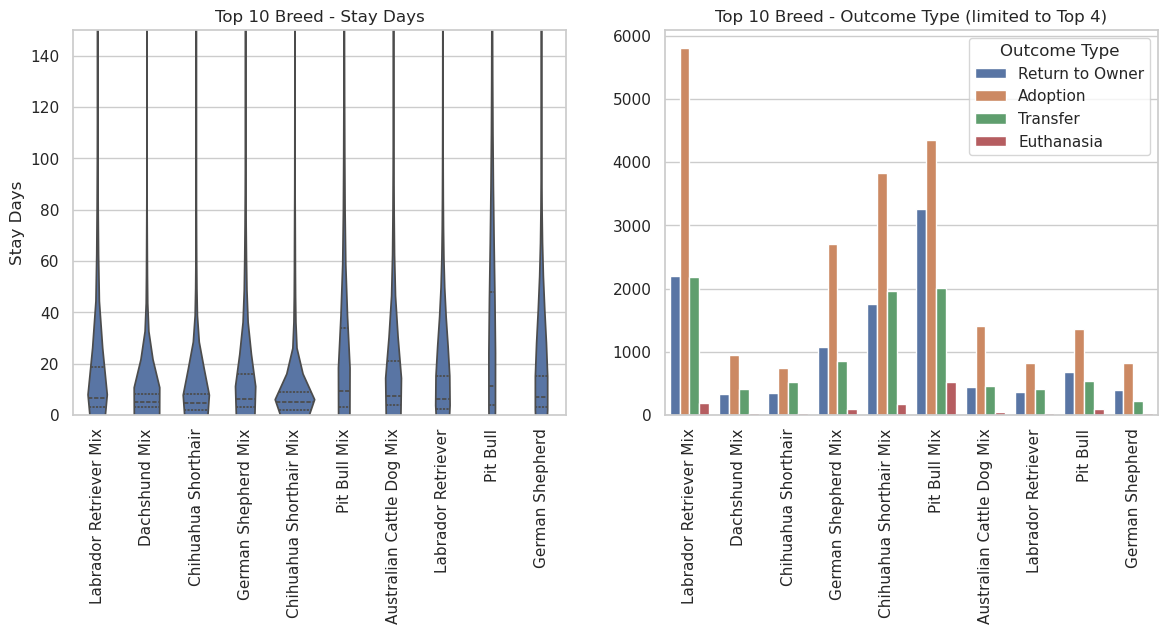

In [131]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.violinplot(data = filtered,y = "Stay Days", x = "Breed", ax = axes[0], inner = "quartile")
axes[0].set_title("Top 10 Breed - Stay Days")
axes[0].set_xlabel("")
axes[0].set_ylim(0,150)
axes[0].tick_params(axis='x', rotation=90)
sns.countplot(data = filtered_out, x="Breed", hue="Outcome Type", ax = axes[1])
axes[1].set_title("Top 10 Breed - Outcome Type (limited to Top 4)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=90)
plt.show()

In [119]:
filtered.groupby("Breed")["Stay Days"].mean()

Breed
Australian Cattle Dog Mix   26.61
Chihuahua Shorthair         12.69
Chihuahua Shorthair Mix     12.78
Dachshund Mix               11.98
German Shepherd             26.07
German Shepherd Mix         21.52
Labrador Retriever          24.71
Labrador Retriever Mix      27.08
Pit Bull                    73.63
Pit Bull Mix                45.90
Name: Stay Days, dtype: float64

## 10. Breed Analysis (Top 10)

### 10.1 Breed Simplification

The original dataset contained 2,554 unique breed entries, including crossbreeds notated with "/" (e.g., "Siberian Husky/Chow Chow"). To reduce dimensionality, crossbreeds were simplified by extracting the primary breed and appending "Mix":

```python
def to_mix(string):
    if "/" in string:
        string = string.split("/")[0] + " Mix"
    return string

df_copy["Breed"] = df_copy["Breed"].apply(to_mix) 
```
This reduced the number of unique breeds significantly while preserving the primary breed signal.

### 10.2 Top 10 Breeds by Intake Volume

|Rank	|Breed	|Count|
|-------|-------|------------|
|1|Labrador Retriever Mix|       10,570|
|2|Pit Bull Mix                 |10,444|
|3|Chihuahua Shorthair Mix       |7,810|
|4|German Shepherd Mix           |4,787|
|5|Pit Bull                      |2,867|
|6|Australian Cattle Dog Mix     |2,380|
|7|Dachshund Mix                 |1,736|
|8|Chihuahua Shorthair           |1,690|
|9|Labrador Retriever            |1,675|
|10|German Shepherd               |1,509|


**Observation:** The top 4 breeds are all "Mix" variants, confirming that mixed breeds dominate shelter intakes. Labrador Retriever Mix is the single most common breed representation.

### 10.3 Stay Duration by Breed
|Breed	|Median (Days)|	Mean (Days)|	Mean/Median Ratio	|Skewness|
|--------|------------|------------|---------------------------|-------|
|Pit Bull	|11.36	|73.63	|6.5x	|Extremely right-skewed|
|Pit Bull Mix|	9.20|	45.90	|5.0x	|Highly right-skewed|
|Labrador Retriever Mix	|6.79	|27.08	|4.0x	|Right-skewed|
|Australian Cattle Dog Mix	|7.50	|26.61|	3.5x	|Right-skewed|
|Labrador Retriever|	6.18	|24.71|	4.0x|	Right-skewed|
|German Shepherd Mix	|6.35	|21.52	|3.4x|	Right-skewed|
|German Shepherd	|6.93	|26.07	|3.8x	|Right-skewed|
|Chihuahua Shorthair Mix	|4.95	|12.78	|2.6x|	Moderately skewed|
|Dachshund Mix	|4.97	|11.98|	2.4x|	Moderately skewed|
|Chihuahua Shorthair	|4.77|	12.69|	2.7x|	Moderately skewed|

**Key Findings**

  1.  **Pit Bulls stay longest:** Both purebred (median 11.4 days, mean 73.6 days) and mixed (median 9.2 days, mean 45.9 days) Pit Bulls show significantly longer stays than any other breed. The extreme mean/median ratio (6.5x) indicates a substantial subgroup of Pit Bulls with very prolonged stays — likely due to breed-specific legislation, housing restrictions, insurance limitations, and public stigma.
2. **Labrador surprise:** Despite being widely regarded as "America's favorite dog," Labradors show unexpectedly high mean stay durations (~25 days). While the median (6.2 days) suggests most are adopted quickly, the high mean indicates a meaningful subset that stays long-term — possibly due to behavioral issues or health concerns in surrendered individuals.
3.    **Small breeds exit fastest:** Chihuahuas (purebred and mixed) and Dachshund Mixes consistently show the shortest stays (median < 5 days, mean < 13 days). This suggests adopter preference for smaller dogs or faster turnover for these breeds.
4.    **Purebreed vs. Mix:** Within the same breed (e.g., Pit Bull vs. Pit Bull Mix, Chihuahua vs. Chihuahua Mix), purebreds tend to show slightly more extreme distributions - Pit Bulls more so than Pit Bull Mixes, suggesting that breed-specific barriers (legislation, insurance) may hit purebreds harder.
